Laplace-Beltrami eigenmodes/eigenvalues cannot be computed directly for geometry defined as a voxel
mask--instead, we need a mesh. In this tutorial we will look at using `make_vol_mesh()` to construct
a tetrahedral mesh (`lapy.TetMesh`) from NIFTI masks of the left hippocampus, striatum, and
thalamus. For mesh stability, extra vertices will be added, meaning that mode-based analysis of
NIFTI data (e.g., decomposition of hippocampal gene expression into modal loadings) requires the
data to first be projected onto the mesh. This is handled by `nifti_to_tetmesh()`, which uses a
combination of linear interpolation in the mesh's interior and radial basis function extrapolation
near its boundary.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nibabel.loadsave import load
from nibabel.nifti1 import Nifti1Image

from neuromodes import EigenSolver
from neuromodes.mesh import make_vol_mesh, nifti_to_tetmesh


In [2]:
# Setup paths
data_dir = "C:/Users/ipop0003/neuromodes/neuromodes/data"
structures = ["hippo", "striatum", "tha"]
nifti_paths = [f"{data_dir}/hcp_{s}-lh_thr25.nii.gz" for s in structures]

### `make_vol_mesh()`

In [3]:
# Try meshing the left hippocampus
mesh_hippo = make_vol_mesh(nifti_paths[0])
n_voxels_hippo = load(nifti_paths[0]).get_fdata().sum()
print(f"Hippocampal voxels: {n_voxels_hippo}, Mesh vertices: {mesh_hippo.v.shape[0]}")

Hippocampal voxels: 952.0, Mesh vertices: 2178


In [4]:
# Compute eigenmode 2
emode2_hippo = EigenSolver(mesh_hippo).solve(2).emodes[:, -1]

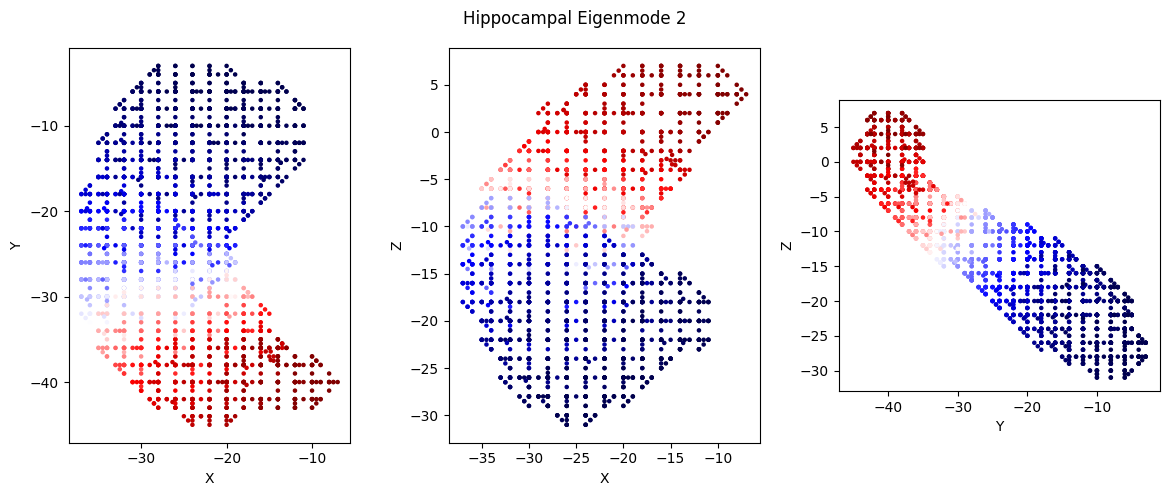

In [5]:
# Visualise
s = 5
cmap = 'seismic'
figsize = (12, 5)
fig, axs = plt.subplots(1, 3, figsize=figsize)

plt.suptitle("Hippocampal Eigenmode 2")
axs[0].scatter(mesh_hippo.v[:, 0], mesh_hippo.v[:, 1], c=emode2_hippo, s=s, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')
axs[1].scatter(mesh_hippo.v[:, 0], mesh_hippo.v[:, 2], c=emode2_hippo, s=s, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')
axs[2].scatter(mesh_hippo.v[:, 1], mesh_hippo.v[:, 2], c=emode2_hippo, s=s, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


In [ ]:
# Try meshing the left striatum
# NOTE: since the striatal mask has some voxels that only share an edge/corner with the mainland,
# the marching cubes algorithm will produce a surface boundary with multiple connected components.
# This is a problem that needs to be addressed before tetrahedralisation, so make_vol_mesh() will
# raise a warning and return a tuple consisting of the mesh and the connected component labels for
# each vertex. The user can then inspect the connected components and decide whether to recall
# make_vol_mesh() with discard_components=True, to retain only the largest connected component, or
# closings>0 to perform binary closings on the marching cubes surface to fill holes and join
# disconnected components. Note that this API is likely to change in the future.
mesh_striatum = make_vol_mesh(nifti_paths[1])

C:\Users\ipop0003\neuromodes\neuromodes\mesh.py:523: UserWarning: Generated surface has 2 connected components; unable to proceed with tetrahedral meshing. Surface mesh will be returned with labels array to allow visual inspection. Consider using `discard_components` to keep only the largest component, or `closings` to fill small holes and merge disconnected pieces.
  warn(f"Generated surface has {n_components} connected components; unable to proceed "


In [ ]:
# Inspect the number of vertices in each connected component of the striatum marching cubes mesh
n_components, component_sizes = np.unique(mesh_striatum[1], return_counts=True)
print(f"Striatum mesh has {n_components.size} connected components with sizes: {component_sizes}")

Striatum mesh has 2 connected components with sizes: [1765    6]


In [8]:
# Try joining the striatum mesh components into a single mesh
mesh_striatum = make_vol_mesh(nifti_paths[1], closings=1)
n_voxels_striatum = load(nifti_paths[1]).get_fdata().sum()
print(f"Striatal voxels: {n_voxels_striatum}, Mesh vertices: {mesh_striatum.v.shape[0]}")

Striatal voxels: 1896.0, Mesh vertices: 3924


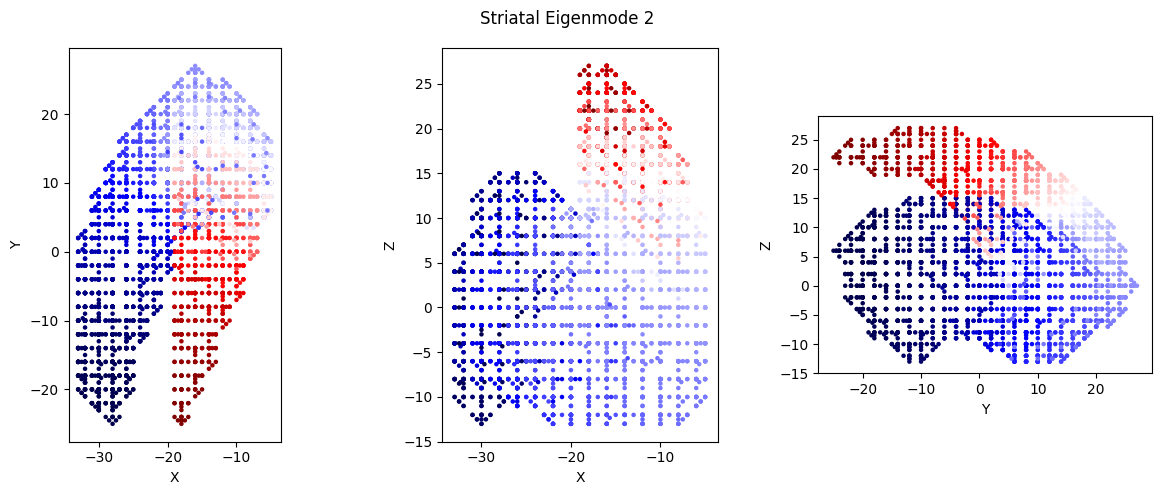

In [9]:
# Compute eigenmode 2
emode2_striatum = EigenSolver(mesh_striatum).solve(2).emodes[:, -1]

# Visualise
fig, axs = plt.subplots(1, 3, figsize=figsize)
plt.suptitle("Striatal Eigenmode 2")

axs[0].scatter(mesh_striatum.v[:, 0], mesh_striatum.v[:, 1], c=emode2_striatum, s=5, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')

axs[1].scatter(mesh_striatum.v[:, 0], mesh_striatum.v[:, 2], c=emode2_striatum, s=5, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')

axs[2].scatter(mesh_striatum.v[:, 1], mesh_striatum.v[:, 2], c=emode2_striatum, s=5, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [10]:
# Try meshing the left thalamus
mesh_tha = make_vol_mesh(nifti_paths[2])
n_voxels_tha = load(nifti_paths[2]).get_fdata().sum()
print(f"Thalamic voxels: {n_voxels_tha}, Mesh vertices: {mesh_tha.v.shape[0]}")

Thalamic voxels: 1532.0, Mesh vertices: 2758


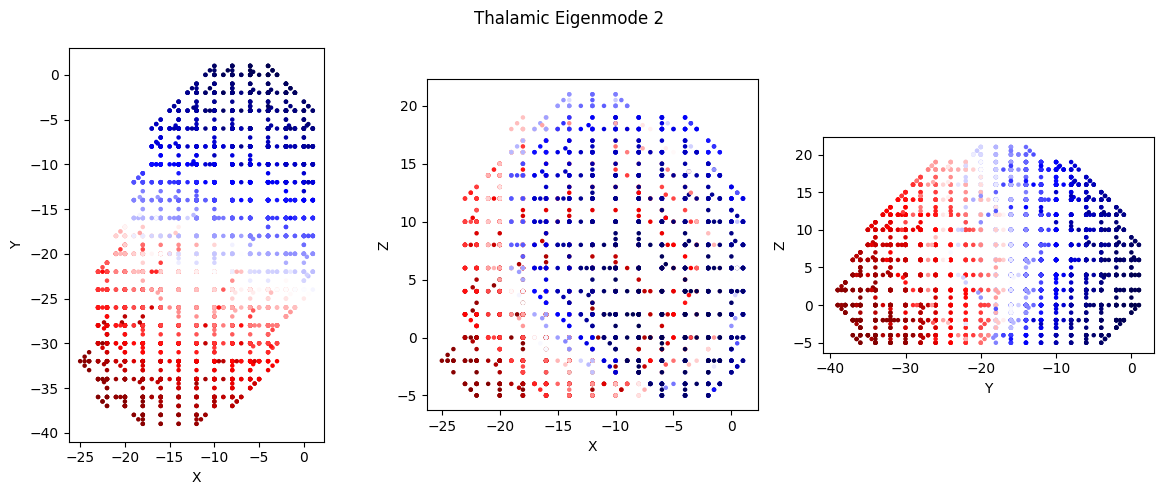

In [11]:
# Compute eigenmode 2
emode2_tha = EigenSolver(mesh_tha).solve(2).emodes[:, -1]

# Visualise
fig, axs = plt.subplots(1, 3, figsize=figsize)
plt.suptitle("Thalamic Eigenmode 2")

axs[0].scatter(mesh_tha.v[:, 0], mesh_tha.v[:, 1], c=emode2_tha, s=5, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')

axs[1].scatter(mesh_tha.v[:, 0], mesh_tha.v[:, 2], c=emode2_tha, s=5, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')

axs[2].scatter(mesh_tha.v[:, 1], mesh_tha.v[:, 2], c=emode2_tha, s=5, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

### `nifti_to_tetmesh()`

In [32]:
# Construct a NIFTI with some example data to project onto the hippocampal mesh
# Here we use the x-coordinates of the voxels
data_hippo = load(nifti_paths[0])
nonzeros = np.nonzero(data_hippo.get_fdata())
x_coords = np.zeros(data_hippo.shape)
x_coords[nonzeros] = nonzeros[0]
data_hippo = Nifti1Image(x_coords, data_hippo.affine, data_hippo.header)

# Project/interpolate onto tetrahedral mesh
data_hippo_mesh = nifti_to_tetmesh(data_hippo, mesh_hippo, nifti_paths[0])

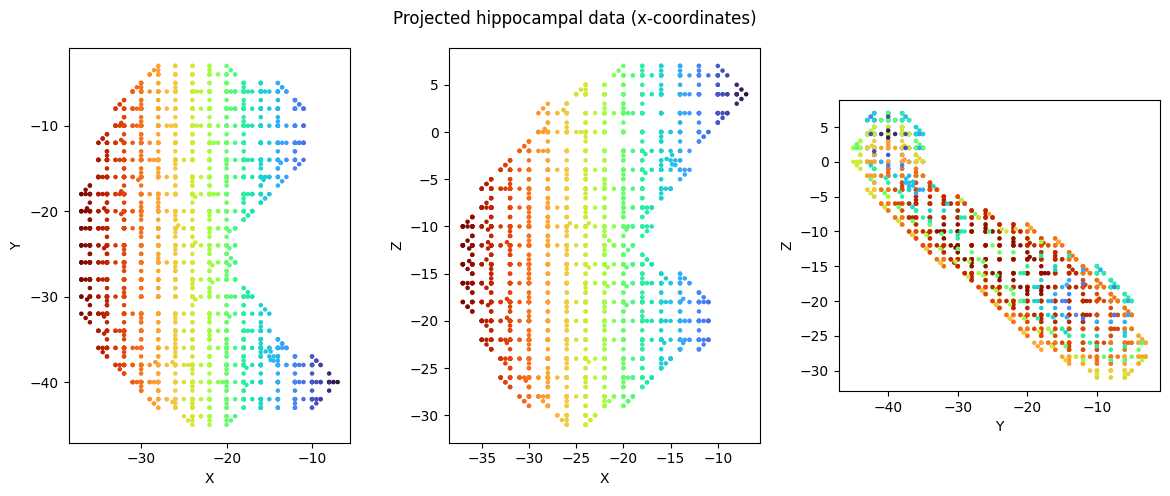

In [33]:
# Visualise
cmap = 'turbo'

fig, axs = plt.subplots(1, 3, figsize=figsize)
plt.suptitle("Projected hippocampal data (x-coordinates)")

axs[0].scatter(mesh_hippo.v[:, 0], mesh_hippo.v[:, 1], c=data_hippo_mesh, s=5, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')
axs[1].scatter(mesh_hippo.v[:, 0], mesh_hippo.v[:, 2], c=data_hippo_mesh, s=5, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')
axs[2].scatter(mesh_hippo.v[:, 1], mesh_hippo.v[:, 2], c=data_hippo_mesh, s=5, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [34]:
# Construct a NIFTI with some example data to project onto the striatal mesh
# Here we use the x-coordinates of the voxels
data_striatum = load(nifti_paths[1])
nonzeros = np.nonzero(data_striatum.get_fdata())
x_coords = np.zeros(data_striatum.shape)
x_coords[nonzeros] = nonzeros[0]
data_striatum = Nifti1Image(x_coords, data_striatum.affine, data_striatum.header)

# Project/interpolate onto tetrahedral mesh
data_striatum_mesh = nifti_to_tetmesh(data_striatum, mesh_striatum, nifti_paths[1])

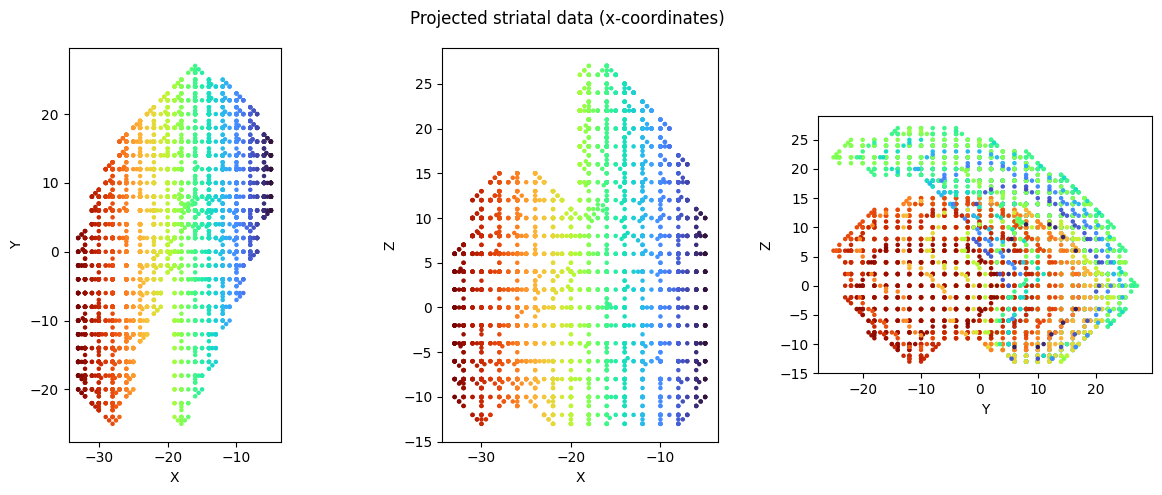

In [35]:
# Visualise
fig, axs = plt.subplots(1, 3, figsize=figsize)
plt.suptitle("Projected striatal data (x-coordinates)")

axs[0].scatter(mesh_striatum.v[:, 0], mesh_striatum.v[:, 1], c=data_striatum_mesh, s=5, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')
axs[1].scatter(mesh_striatum.v[:, 0], mesh_striatum.v[:, 2], c=data_striatum_mesh, s=5, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')
axs[2].scatter(mesh_striatum.v[:, 1], mesh_striatum.v[:, 2], c=data_striatum_mesh, s=5, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [36]:
# Construct a NIFTI with some example data to project onto the thalamic mesh
# Here we use the x-coordinates of the voxels
data_tha = load(nifti_paths[1])
nonzeros = np.nonzero(data_tha.get_fdata())
x_coords = np.zeros(data_tha.shape)
x_coords[nonzeros] = nonzeros[0]
data_tha = Nifti1Image(x_coords, data_tha.affine, data_tha.header)

# Project/interpolate onto tetrahedral mesh
data_tha_mesh = nifti_to_tetmesh(data_tha, mesh_tha, nifti_paths[1])

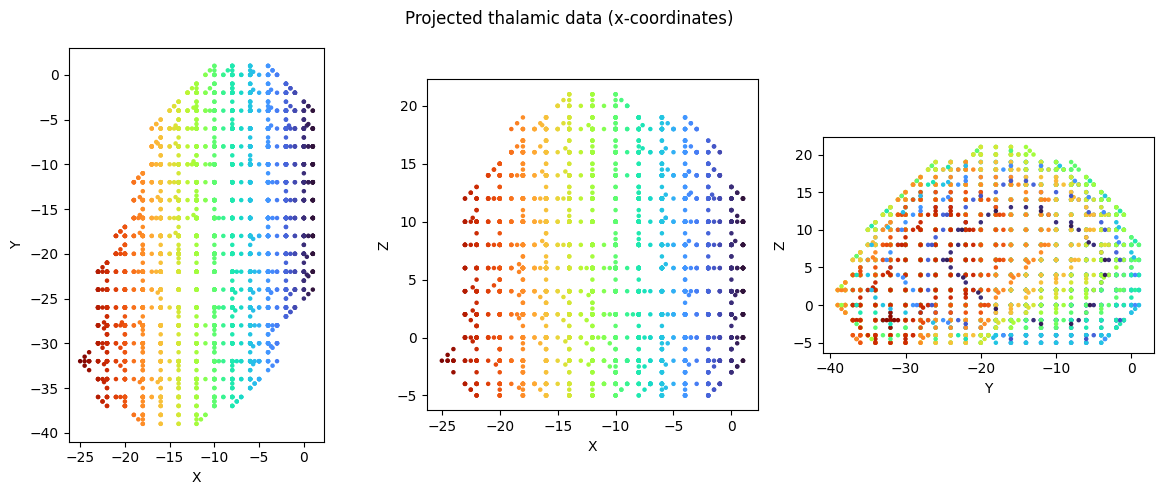

In [37]:
# Visualise
fig, axs = plt.subplots(1, 3, figsize=figsize)
plt.suptitle("Projected thalamic data (x-coordinates)")

axs[0].scatter(mesh_tha.v[:, 0], mesh_tha.v[:, 1], c=data_tha_mesh, s=5, cmap=cmap)
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")
axs[0].set_aspect('equal', adjustable='box')
axs[1].scatter(mesh_tha.v[:, 0], mesh_tha.v[:, 2], c=data_tha_mesh, s=5, cmap=cmap)
axs[1].set_xlabel("X")
axs[1].set_ylabel("Z")
axs[1].set_aspect('equal', adjustable='box')
axs[2].scatter(mesh_tha.v[:, 1], mesh_tha.v[:, 2], c=data_tha_mesh, s=5, cmap=cmap)
axs[2].set_xlabel("Y")
axs[2].set_ylabel("Z")
axs[2].set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()